### Install dependencies

In [4]:
!pip install folium pandas
!pip install shapely

In [5]:
import boto3
import pandas as pd
import io
from botocore.exceptions import ClientError
from shapely.geometry import Point, Polygon
import math
import folium
from folium import plugins
import numpy as np
import folium
import pandas as pd
from typing import Optional, Union, Tuple
import json
from ipywidgets import interact, FloatSlider, Layout
import ipywidgets as widgets
import boto3
import pandas as pd
import io
from botocore.exceptions import ClientError
from shapely.geometry import Point, Polygon
import math
import folium
from folium import plugins
import numpy as np
import folium
import pandas as pd
from typing import Optional, Union, Tuple
import json
from ipywidgets import interact, FloatSlider, Layout
import ipywidgets as widgets
from shapely.vectorized import contains
import s3fs

### Support Functions

#### Read CSV

In [6]:
def read_csv_from_s3_with_options(bucket_name, file_key, **kwargs):
    """
    Enhanced version with additional pandas read_csv options
    
    Parameters:
    bucket_name (str): Name of the S3 bucket
    file_key (str): Path to the CSV file in the bucket
    **kwargs: Additional arguments to pass to pd.read_csv()
    
    Returns:
    pandas.DataFrame: DataFrame containing the CSV data
    """
    try:
        # Create an S3 client
        s3_client = boto3.client('s3')
        
        # Get the object from S3
        response = s3_client.get_object(Bucket=bucket_name, Key=file_key)
        
        # Read the CSV content with additional options
        df = pd.read_csv(io.BytesIO(response['Body'].read()), **kwargs)
        
        return df
    
    except Exception as e:
        print(f"Error reading CSV file from S3: {str(e)}")
        raise



#### Adjust radius and color for maps depending on values

In [7]:
def scale_radius(bird_count, min_birds, max_birds):
    """Scale the radius of circles based on bird count"""
    min_radius = 2
    max_radius = 20
    return min_radius + (max_radius - min_radius) * ((bird_count - min_birds) / (max_birds - min_birds))

def get_color(bird_count):
    """Return color based on bird count ranges"""
    # Calculate quartiles for better distribution
    q1 = df['total_birds'].quantile(0.25)
    q2 = df['total_birds'].quantile(0.5)
    q3 = df['total_birds'].quantile(0.75)
    
    if bird_count <= q1:
        return '#d7191c'  # Red'
    elif bird_count <= q2:
        return 'fdae61'  # Orange
    elif bird_count <= q3:
        return '2b83ba'  # Light blue'
    else:
        return '#abdda4'  # Light green

#### Create point layer

In [8]:
##v2
def create_point_layer(df, latitude, longitude, id, bird_observations, traffic_noise):
    """
    Create a feature group with points scaled by bird observations and colored by traffic noise.
    
    Args:
        df (pd.DataFrame): DataFrame containing the point data
        latitude (str): Name of latitude column
        longitude (str): Name of longitude column
        id (str): Name of ID column
        bird_observations (str): Name of bird observations column
        traffic_noise (str): Name of traffic noise column
    
    Returns:
        folium.FeatureGroup: Layer containing all points
    """
    # Create feature group
    point_layer = folium.FeatureGroup(name='Observation Points')

    # Remove any NaN values
    df = df.dropna(subset=[bird_observations, traffic_noise])
    
    if len(df) == 0:
        return point_layer
    
    # Calculate scales for size and color
    min_birds = df[bird_observations].min()
    max_birds = df[bird_observations].max()
    min_noise = df[traffic_noise].min()
    max_noise = df[traffic_noise].max()
    
    # Create scaling functions
    def scale_radius(value):
        # Scale radius between 5 and 25 pixels
        return 5 + ((value - min_birds) / (max_birds - min_birds)) * 20
    
    def scale_color(value):
        # Create color scale from green (quiet) to red (noisy)
        normalized = (value - min_noise) / (max_noise - min_noise)
        return f'#{int(255 * normalized):02x}{int(255 * (1-normalized)):02x}00'
    
    # Add points to layer
    for idx, row in df.iterrows():
        # Calculate radius and color
        radius = scale_radius(row[bird_observations])
        color = scale_color(row[traffic_noise])
        
        # Create popup content
        popup_content = f"""
            <b>Station ID:</b> {row[id]}<br>
            <b>Bird Observations:</b> {row[bird_observations]}<br>
            <b>Traffic Noise:</b> {row[traffic_noise]:.2f}<br>
        """
        
        # Add circle marker
        folium.CircleMarker(
            location=[row[latitude], row[longitude]],
            radius=radius,
            popup=folium.Popup(popup_content, max_width=300),
            color='black',
            weight=1,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            tooltip=f"Station {row[id]}"
        ).add_to(point_layer)
    
    # Add legend for size
    legend_html = f"""
        <div style="position: fixed; 
                    bottom: 50px; right: 50px; width: 150px; height: 90px; 
                    border:2px solid grey; z-index:9999; background-color:white;
                    padding: 10px;
                    font-size: 14px;">
            <p><b>Legend:</b></p>
            <p>🔴 Size: Bird Observations<br>
               ({min_birds:.0f} - {max_birds:.0f})</p>
            <p>🎨 Color: Traffic Noise<br>
               ({min_noise:.1f} - {max_noise:.1f})</p>
        </div>
    """
    point_layer.add_child(folium.Element(legend_html))
    
    return point_layer

#### Add point to map 

In [9]:
def add_df_point_to_map(df, m):
    """
    Add points from DataFrame to map with size and color based on total_birds
    
    Parameters:
    df: DataFrame containing latitude, longitude, and total_birds
    m: folium Map object
    
    Returns:
    feature_group: Folium FeatureGroup containing all markers
    """

    min_birds = df['total_birds'].min()
    max_birds = df['total_birds'].max()
    
    # Create a feature group for the data points
    feature_group = folium.FeatureGroup(name='Bird Observations')
    
    # Add points to feature group
    for idx, row in df.iterrows():
        folium.CircleMarker(
            location=[row['Lat'], row['Long']],
            radius=scale_radius(row['total_birds'], min_birds, max_birds),
            color=get_color(row['total_birds']),
            fill=True,
            fill_color=get_color(row['total_birds']),
            fill_opacity=0.7,
            popup=f"Total Birds: {row['total_birds']}",
            tooltip=f"Location: ({row['Lat']:.2f}, {row['Long']:.2f})\nTotal Birds: {row['total_birds']}"
        ).add_to(feature_group)
    
    # Add the feature group to the map
    feature_group.add_to(m)
    
    # Add a legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; 
                border:2px solid grey; z-index:9999; font-size:14px;
                background-color: white;
                padding: 10px;
                border-radius: 5px;
                ">
    <p><b>Bird Count Legend</b></p>
    <p>
    <i class="fa fa-circle" style="color:blue"></i> Low<br>
    <i class="fa fa-circle" style="color:yellow"></i> Medium<br>
    <i class="fa fa-circle" style="color:orange"></i> High<br>
    <i class="fa fa-circle" style="color:red"></i> Very High
    </p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Return the feature group
    return feature_group

#### Calculate distance between points (miles)

In [10]:
# Calculate distance between points (approximate, in miles)
def calculate_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two points using Haversine formula
    Returns distance in miles
    """
    R = 3959.87433  # Earth's radius in miles

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


#### Create bounded area

In [11]:
def create_bounded_polygon(top_coordinate, bottom_coordinate, path_coordinates, buffer_miles=0.1, color='blue', fill_color='blue'):
    """
    Create a polygon layer for folium that extends east and west from a path of coordinates.
    
    Returns:
    tuple: (folium.FeatureGroup, shapely.geometry.Polygon) - The Folium layer and the Shapely polygon
    """
    # Convert buffer miles to degrees (approximate)
    avg_lat = (top_coordinate[0] + bottom_coordinate[0]) / 2
    buffer_degrees = buffer_miles / (math.cos(math.radians(avg_lat)) * 69)
    
    # Create points for the left and right sides of the polygon
    left_points = []
    right_points = []
    
    # Add top point to both sides
    left_points.append([top_coordinate[0], top_coordinate[1] - buffer_degrees])
    right_points.append([top_coordinate[0], top_coordinate[1] + buffer_degrees])
    
    # Create points along the path
    for lat, lon in path_coordinates:
        left_points.append([lat, lon - buffer_degrees])
        right_points.append([lat, lon + buffer_degrees])
    
    # Add bottom point to both sides
    left_points.append([bottom_coordinate[0], bottom_coordinate[1] - buffer_degrees])
    right_points.append([bottom_coordinate[0], bottom_coordinate[1] + buffer_degrees])
    
    # Combine points to form a polygon (going down the left side and up the right side)
    polygon_points = left_points + right_points[::-1] + [left_points[0]]
    
    # Create a Shapely polygon (note the coordinate order swap for Shapely)
    shapely_points = [(lon, lat) for lat, lon in polygon_points]
    shapely_polygon = Polygon(shapely_points)
    
    # Create a feature group
    feature_group = folium.FeatureGroup(name="Bounded Polygon")
    
    # Add the polygon to the feature group
    folium.Polygon(
        locations=polygon_points,
        color=color,
        fill=True,
        fill_color=fill_color,
        fill_opacity=0.2,
        weight=2,
        popup='Bounded Area'
    ).add_to(feature_group)
    
    return feature_group, shapely_polygon

In [12]:
def save_polygon_to_json(polygon, filename='bounded_polygon.json'):
    """
    Save polygon geometry to JSON file.
    
    Args:
        polygon: Shapely Polygon object
        filename (str): Output filename (default: 'bounded_polygon.json')
    """
    try:
        # Convert Shapely polygon to coordinate list
        if hasattr(polygon, 'exterior'):
            coords = [[x, y] for x, y in polygon.exterior.coords]
        else:
            coords = polygon  # In case it's already a list of coordinates
            
        # Convert to GeoJSON format
        geojson = {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [coords]  # Note: GeoJSON requires nested array
            }
        }
        
        # Save to file
        with open(filename, 'w') as f:
            json.dump(geojson, f, indent=2)
            
        print(f"Successfully saved polygon to {filename}")
        
    except Exception as e:
        print(f"Error saving polygon to JSON: {str(e)}")
        raise

In [13]:
def filter_by_bounded_area(df, polygon, lat_col="latitude", lon_col="longitude"):
    """
    Filter DataFrame to only include points that fall within the given polygon
    
    Parameters:
    df: pandas DataFrame containing latitude and longitude columns
    polygon: shapely Polygon object defining the bounded area
    lat_col: name of latitude column (default: "latitude")
    lon_col: name of longitude column (default: "longitude")
    
    Returns:
    pandas DataFrame containing only the rows within the polygon
    """
    # Create a mask of points that fall within the polygon
    mask = df.apply(
        lambda row: polygon.contains(Point(row[lon_col], row[lat_col])), 
        axis=1
    )
    
    # Return filtered DataFrame
    return df[mask]

#### Slicers for noise and observations

In [14]:
def create_filtered_layer(noise_threshold, bird_threshold, df):
    """
    Create a feature group with points filtered by both noise and bird observation thresholds
    
    Args:
        noise_threshold (float): Maximum noise level threshold
        bird_threshold (float): Minimum bird observations threshold
        df (pd.DataFrame): DataFrame with station data
    
    Returns:
        folium.FeatureGroup: Filtered point layer
    """
    # Filter data based on both thresholds
    filtered_df = df[
        (df['daily_avg_noise'] <= noise_threshold) & 
        (df['bird_observations'] >= bird_threshold)
    ]
    
    # Create and return filtered point layer
    return create_point_layer(
        df=filtered_df,
        latitude='latitude',
        longitude='longitude',
        id='station_id',
        bird_observations='bird_observations',
        traffic_noise='daily_avg_noise'
    )

### Read Data
#### Training Data

In [12]:
# Initialize boto3 session and get credentials
session = boto3.Session()
credentials = session.get_credentials()

# Initialize S3 filesystem with boto3 credentials
s3 = s3fs.S3FileSystem(
    key=credentials.access_key,
    secret=credentials.secret_key,
    token=credentials.token,  # This will be included if using temporary credentials
    anon=False
)
# Read the parquet file
s3_path = 's3://birdsbucker/trainingdata/merged_data_8am_migration_weekend_weather_flag.parquet'
df_birds = pd.read_parquet(s3_path, filesystem=s3)

df_birds.head()

,OBSERVATION COUNT,STATE CODE,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,TIME OBSERVATIONS STARTED,i95_distance,station_distances,assigned_station,...,restrictions,daily_avg_noise,peak_hour_noise,overnight_noise,rush_hour_noise,total_daily_volume,noise_8am,is_weekend,is_migration,extreme_weather
0,2,US-VA,H,38.146335,-77.443370,2020-01-15,08:50:00,0.875569,"{'000019': 1019.9471111116882, '000022': 958.2...",060164,...,0.0,91.648049,94.189788,88.499913,93.493016,78503.0,93.963317,0.0,0,0
1,1,US-VA,P,38.183491,-77.424592,2020-01-15,08:27:00,0.386942,"{'000019': 1015.7567282177127, '000022': 954.0...",060164,...,0.0,91.648049,94.189788,88.499913,93.493016,78503.0,93.963317,0.0,0,0
2,2,US-VA,H,38.146335,-77.443370,2020-01-15,08:50:00,0.875569,"{'000019': 1019.9471111116882, '000022': 958.2...",060164,...,0.0,91.648049,94.189788,88.499913,93.493016,78503.0,93.963317,0.0,0,0
3,1,US-VA,P,38.183491,-77.424592,2020-01-15,08:27:00,0.386942,"{'000019': 1015.7567282177127, '000022': 954.0...",060164,...,0.0,91.648049,94.189788,88.499913,93.493016,78503.0,93.963317,0.0,0,0
4,2,US-VA,H,38.148066,-77.440200,2020-01-15,08:36:00,0.732355,"{'000019': 1019.61976246388, '000022': 957.962...",060164,...,0.0,91.648049,94.189788,88.499913,93.493016,78503.0,93.963317,0.0,0,0


#### Clean Data

In [13]:
# First, let's see what columns we actually have
print("Available columns:", df_birds.columns.tolist())

# More robust approach handling potential format variations
def convert_to_time(time_str):
    try:
        return pd.to_datetime(time_str).time()
    except:
        return pd.NaT

# Now let's try to find the correct column name for time
time_columns = [col for col in df_birds.columns if 'TIME' in col.upper()]
print("\nColumns containing 'TIME':", time_columns)

# If we find the correct column, let's use it
if time_columns:
    correct_column = time_columns[0]  # Use the first matching column
    df_birds[correct_column] = df_birds[correct_column].apply(convert_to_time)
    
    # Verify the conversion
    print(f"\nData type: {df_birds[correct_column].dtype}")
    print("\nFirst few values:")
    print(df_birds[correct_column].head())
    print(f"\nNumber of null values: {df_birds[correct_column].isnull().sum()}")
else:
    print("\nNo time-related columns found. Please check the column names.")

Available columns: ['OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE', 'LATITUDE', 'LONGITUDE', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED', 'i95_distance', 'station_distances', 'assigned_station', 'year_record', 'month_record', 'day_record', 'hour_started', 'state_code', 'day_of_week', 'latitude', 'longitude', 'station_location', 'state', 'hour_00', 'hour_01', 'hour_02', 'hour_03', 'hour_04', 'hour_05', 'hour_06', 'hour_07', 'hour_08', 'hour_09', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'record_type', 'f_system', 'restrictions', 'daily_avg_noise', 'peak_hour_noise', 'overnight_noise', 'rush_hour_noise', 'total_daily_volume', 'noise_8am', 'is_weekend', 'is_migration', 'extreme_weather']

Columns containing 'TIME': ['TIME OBSERVATIONS STARTED']

Data type: object

First few values:
0    08:50:00
1    08:27:00
2    08:50:00
3    08:27:00
4    08:36:00
Name: TIME OBSERVATI

In [14]:
df_birds= df_birds[['OBSERVATION COUNT', 'STATE CODE', 'LOCALITY TYPE', 'LATITUDE',
       'LONGITUDE', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED',
       'i95_distance', 'assigned_station', 'year_record',
       'month_record', 'day_record', 'hour_started', 'state_code',
       'day_of_week', 'latitude', 'longitude',  'state', 'noise_8am','is_migration', 'is_weekend',
       'extreme_weather']]

df_birds.head()

,OBSERVATION COUNT,STATE CODE,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,TIME OBSERVATIONS STARTED,i95_distance,assigned_station,year_record,...,hour_started,state_code,day_of_week,latitude,longitude,state,noise_8am,is_migration,is_weekend,extreme_weather
0,2,US-VA,H,38.146335,-77.443370,2020-01-15,08:50:00,0.875569,060164,2020,...,8,51.0,4.0,38.14136,-77.50652,VA,93.963317,0,0.0,0
1,1,US-VA,P,38.183491,-77.424592,2020-01-15,08:27:00,0.386942,060164,2020,...,8,51.0,4.0,38.14136,-77.50652,VA,93.963317,0,0.0,0
2,2,US-VA,H,38.146335,-77.443370,2020-01-15,08:50:00,0.875569,060164,2020,...,8,51.0,4.0,38.14136,-77.50652,VA,93.963317,0,0.0,0
3,1,US-VA,P,38.183491,-77.424592,2020-01-15,08:27:00,0.386942,060164,2020,...,8,51.0,4.0,38.14136,-77.50652,VA,93.963317,0,0.0,0
4,2,US-VA,H,38.148066,-77.440200,2020-01-15,08:36:00,0.732355,060164,2020,...,8,51.0,4.0,38.14136,-77.50652,VA,93.963317,0,0.0,0


In [15]:
# Check number of rows before dropping
print("Number of rows before:", len(df_birds))

# Drop rows where noise_8am is null
df_birds = df_birds.dropna(subset=['noise_8am'])

# Check number of rows after dropping
print("Number of rows after:", len(df_birds))

# Show info about remaining null values in the dataset
print("\nRemaining null values in the dataset:")
print(df_birds.isnull().sum())

Number of rows before: 132076
Number of rows after: 100465

Remaining null values in the dataset:
OBSERVATION COUNT            0
STATE CODE                   0
LOCALITY TYPE                0
LATITUDE                     0
LONGITUDE                    0
OBSERVATION DATE             0
TIME OBSERVATIONS STARTED    0
i95_distance                 0
assigned_station             0
year_record                  0
month_record                 0
day_record                   0
hour_started                 0
state_code                   0
day_of_week                  0
latitude                     0
longitude                    0
state                        0
noise_8am                    0
is_migration                 0
is_weekend                   0
extreme_weather              0
dtype: int64


In [17]:
# Check number of rows before dropping
print("Number of rows before:", len(df_birds))

# Drop rows where OBSERVATION COUNT is 'X'
df_birds = df_birds[df_birds['OBSERVATION COUNT'] != 'X']

# Check number of rows after dropping
print("Number of rows after:", len(df_birds))

# Convert column to numeric if not already
df_birds['OBSERVATION COUNT'] = pd.to_numeric(df_birds['OBSERVATION COUNT'])

# Verify the changes
print("\nData type:", df_birds['OBSERVATION COUNT'].dtype)
print("\nUnique values:", sorted(df_birds['OBSERVATION COUNT'].unique()))
print("\nNumber of null values:", df_birds['OBSERVATION COUNT'].isnull().sum())

Number of rows before: 100465
Number of rows after: 98501

Data type: int64

Unique values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 102, 103, 104, 105, 106, 108, 109, 110, 111, 112, 114, 115, 118, 119, 120, 121, 122, 123, 125, 128, 129, 130, 132, 133, 135, 137, 139, 140, 143, 144, 145, 146, 147, 148, 150, 152, 153, 154, 155, 158, 160, 162, 163, 165, 166, 168, 170, 172, 174, 175, 177, 178, 179, 180, 181, 182, 185, 186, 187, 188, 190, 193, 195, 196, 199, 200, 206, 210, 211, 212, 213, 214, 215, 220, 224, 225, 226, 227, 230, 231, 235, 240, 243, 244, 245, 250, 255, 257, 260, 265, 270, 275, 277, 280, 285, 289, 290, 296, 297, 300, 305, 310, 312,

/tmp/ipykernel_206/1494081836.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_birds['OBSERVATION COUNT'] = pd.to_numeric(df_birds['OBSERVATION COUNT'])


In [18]:
# Create a summary DataFrame with data types and null counts
summary = pd.DataFrame({
    'Data Type': df_birds.dtypes,
    'Null Count': df_birds.isnull().sum(),
    'Null Percentage': (df_birds.isnull().sum() / len(df_birds) * 100).round(2)
})

# Add total rows count for reference
print(f"Total rows in DataFrame: {len(df_birds)}\n")

# Display the summary
print(summary)

Total rows in DataFrame: 98501

                                Data Type  Null Count  Null Percentage
OBSERVATION COUNT                   int64           0              0.0
STATE CODE                         object           0              0.0
LOCALITY TYPE                      object           0              0.0
LATITUDE                          float64           0              0.0
LONGITUDE                         float64           0              0.0
OBSERVATION DATE           datetime64[ns]           0              0.0
TIME OBSERVATIONS STARTED          object           0              0.0
i95_distance                      float64           0              0.0
assigned_station                   object           0              0.0
year_record                         int32           0              0.0
month_record                         int8           0              0.0
day_record                           int8           0              0.0
hour_started                        int32    

In [25]:
# Group by the specified columns and aggregate with both sum and mean
grouped_df = df_birds.groupby(['assigned_station','latitude','longitude', 
                             'OBSERVATION DATE']).agg({
    'OBSERVATION COUNT': 'sum',
    'noise_8am': 'mean'
}).reset_index()

# Round noise_8am mean to 2 decimal places for cleaner display
grouped_df['noise_8am'] = grouped_df['noise_8am'].round(2)

# Display the first few rows
print("First few rows of the grouped data:")
print(grouped_df.head())

# Display summary statistics
print("\nSummary Statistics:")
print(f"Number of unique stations: {grouped_df['assigned_station'].nunique()}")
print(f"Date range: {grouped_df['OBSERVATION DATE'].min()} to {grouped_df['OBSERVATION DATE'].max()}")
print(f"Total sum of observations: {grouped_df['OBSERVATION COUNT'].sum():,}")  # Removed 's' format specifier
print(f"Average noise level: {grouped_df['noise_8am'].mean():.2f}")

First few rows of the grouped data:
  assigned_station   latitude  longitude OBSERVATION DATE  OBSERVATION COUNT  \
0           030209  44.783583  -68.77135       2020-01-01                  3   
1           030209  44.783583  -68.77135       2020-01-02                  5   
2           030209  44.783583  -68.77135       2020-01-05                 15   
3           030209  44.783583  -68.77135       2020-01-08                  1   
4           030209  44.783583  -68.77135       2020-01-14                 23   

   noise_8am  
0      86.83  
1      92.28  
2      87.27  
3      92.15  
4      92.46  

Summary Statistics:
Number of unique stations: 32
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00
Total sum of observations: 515,533
Average noise level: 90.24


In [26]:
grouped_df

,assigned_station,latitude,longitude,OBSERVATION DATE,OBSERVATION COUNT,noise_8am
0,030209,44.783583,-68.77135,2020-01-01,3,86.83
1,030209,44.783583,-68.77135,2020-01-02,5,92.28
2,030209,44.783583,-68.77135,2020-01-05,15,87.27
3,030209,44.783583,-68.77135,2020-01-08,1,92.15
4,030209,44.783583,-68.77135,2020-01-14,23,92.46
...,...,...,...,...,...,...
8773,792625,37.983110,-77.49229,2021-07-25,1,79.94
8774,792625,37.983110,-77.49229,2022-04-30,1,79.69
8775,792625,37.983110,-77.49229,2022-09-27,4,77.46
8776,792625,37.983110,-77.49229,2022-10-03,11,77.94


### Synthethic data

Total records: 49984

Station distribution:
assigned_station
030209    1562
030210    1562
040099    1562
040101    1562
040105    1562
050701    1562
050909    1562
050910    1562
051623    1562
051624    1562
052103    1562
052104    1562
053103    1562
053104    1562
053801    1562
053802    1562
053901    1562
053902    1562
054201    1562
054202    1562
060162    1562
060164    1562
060170    1562
140004    1562
140005    1562
140006    1562
140313    1562
160005    1562
160006    1562
160007    1562
160308    1562
792625    1562
Name: count, dtype: int64

Station coordinates:
                   latitude  longitude
assigned_station                      
030209            44.783583 -68.771350
030210            44.783583 -68.771350
040099            37.709640 -77.447720
040101            37.754170 -77.458530
040105            37.824110 -77.456160
050701            45.585967 -68.542583
050909            45.223846 -68.675554
050910            45.223846 -68.675554
051623            44.

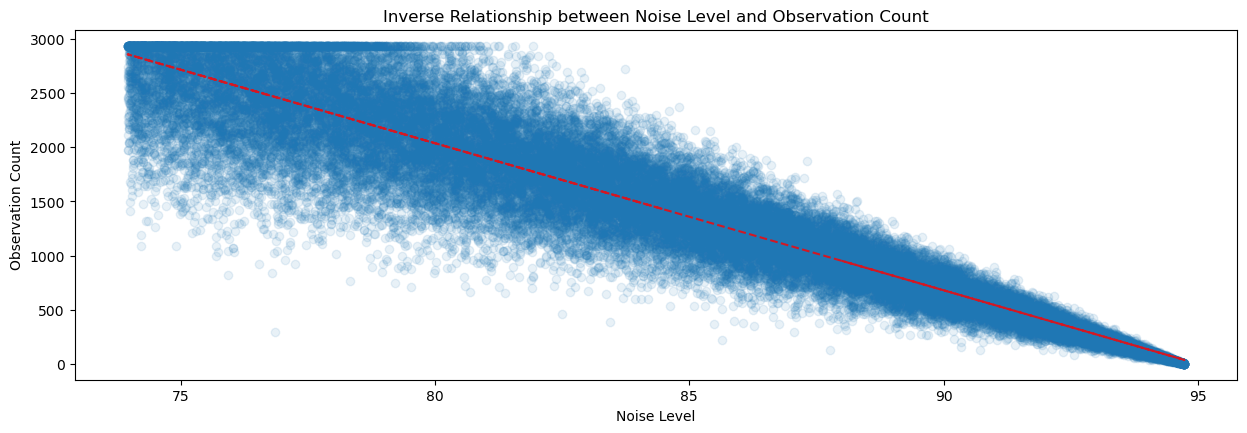

In [32]:
import numpy as np
import pandas as pd

def generate_synthetic_data(grouped_df, target_size=50000):
    # Get unique stations and their coordinates
    station_coords = grouped_df.groupby('assigned_station').agg({
        'longitude': 'first',
        'latitude': 'first'
    }).to_dict('index')
    
    stations = list(station_coords.keys())
    
    # Get min and max values
    min_noise = grouped_df['noise_8am'].min()
    max_noise = grouped_df['noise_8am'].max()
    min_count = grouped_df['OBSERVATION COUNT'].min()
    max_count = grouped_df['OBSERVATION COUNT'].max()
    
    synthetic_data = []
    records_per_station = target_size // len(stations)
    
    for station in stations:
        # Get exact coordinates for this station
        station_longitude = station_coords[station]['longitude']
        station_latitude = station_coords[station]['latitude']
        
        # Generate noise levels
        noise_8ams = np.random.uniform(min_noise, max_noise, size=records_per_station)
        
        # Generate observation counts inversely proportional to noise levels
        normalized_noise = (noise_8ams - min_noise) / (max_noise - min_noise)
        inverse_relationship = 1 - normalized_noise
        
        OBSERVATIONCOUNTs = min_count + (inverse_relationship * (max_count - min_count))
        variation = np.random.normal(1, 0.2, size=len(OBSERVATIONCOUNTs))
        OBSERVATIONCOUNTs = OBSERVATIONCOUNTs * variation
        OBSERVATIONCOUNTs = np.clip(OBSERVATIONCOUNTs, min_count, max_count)
        OBSERVATIONCOUNTs = np.round(OBSERVATIONCOUNTs).astype(int)
        
        for noise, count in zip(noise_8ams, OBSERVATIONCOUNTs):
            synthetic_data.append({
                'noise_8am': round(noise, 2),
                'OBSERVATION COUNT': int(count),
                'assigned_station': station,
                'longitude': station_longitude,
                'latitude': station_latitude
            })
    
    # Convert to DataFrame
    synthetic_df = pd.DataFrame(synthetic_data)
    
    # Ensure exactly target_size records
    if len(synthetic_df) > target_size:
        synthetic_df = synthetic_df.sample(n=target_size, random_state=42)
    
    return synthetic_df

# Generate synthetic data
synthetic_df = generate_synthetic_data(grouped_df, target_size=50000)

# Verify the results
print("Total records:", len(synthetic_df))
print("\nStation distribution:")
print(synthetic_df['assigned_station'].value_counts())
print("\nStation coordinates:")
print(synthetic_df.groupby('assigned_station').agg({
    'latitude': 'first',
    'longitude': 'first'
}))

# Visualizations
import matplotlib.pyplot as plt

# Create a figure with multiple subplots
plt.figure(figsize=(15, 10))

# Plot 1: Noise Level vs Observation Count
plt.subplot(2, 1, 1)
plt.scatter(synthetic_df['noise_8am'], synthetic_df['OBSERVATION COUNT'], alpha=0.1)
plt.xlabel('Noise Level')
plt.ylabel('Observation Count')
plt.title('Inverse Relationship between Noise Level and Observation Count')

# Add trend line
z = np.polyfit(synthetic_df['noise_8am'], synthetic_df['OBSERVATION COUNT'], 1)
p = np.poly1d(z)
plt.plot(synthetic_df['noise_8am'], p(synthetic_df['noise_8am']), "r--", alpha=0.8)



# Calculate correlation
correlation = synthetic_df['noise_8am'].corr(synthetic_df['OBSERVATION COUNT'])
print(f"\nCorrelation between noise level and observation count: {correlation:.2f}")

In [33]:
synthetic_df

,noise_8am,OBSERVATION COUNT,assigned_station,longitude,latitude
0,84.47,1705,030209,-68.77135,44.783583
1,76.76,2522,030209,-68.77135,44.783583
2,83.07,1879,030209,-68.77135,44.783583
3,75.91,2097,030209,-68.77135,44.783583
4,81.56,2036,030209,-68.77135,44.783583
...,...,...,...,...,...
49979,81.26,2247,792625,-77.49229,37.983110
49980,85.01,1894,792625,-77.49229,37.983110
49981,94.32,51,792625,-77.49229,37.983110
49982,94.38,45,792625,-77.49229,37.983110


#### Simulating batch inferencing

Dataset shape: (224, 6)

Sample of the dataset:
  assigned_station  longitude   latitude  OBSERVATION COUNT  noise_8am  \
0           030209 -68.771350  44.783583                 36      91.30   
1           030210 -68.771350  44.783583                 37      91.48   
2           040099 -77.447720  37.709640                 13      92.74   
3           040101 -77.458530  37.754170                 14      91.69   
4           040105 -77.456160  37.824110                 11      91.70   
5           050701 -68.542583  45.585967                 12      81.37   
6           050909 -68.675554  45.223846                 17      82.68   
7           050910 -68.675554  45.223846                 18      84.15   
8           051623 -68.788902  44.814113                 52      91.81   
9           051624 -68.788902  44.814113                 56      90.81   

   noise_projection  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  
5    

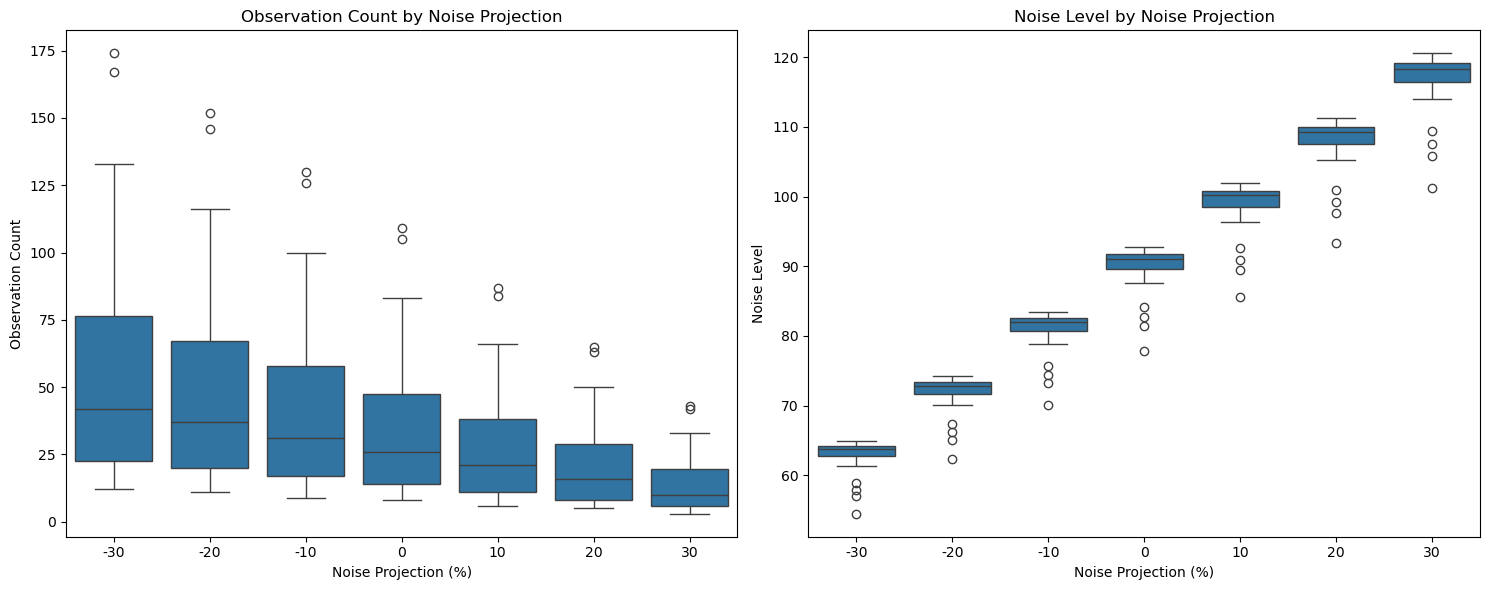


Summary statistics by noise projection:
                 OBSERVATION COUNT          noise_8am                
                              mean min  max      mean     min     max
noise_projection                                                     
-30                          58.78  12  174     62.84   54.48   64.92
-20                          51.47  11  152     71.82   62.27   74.19
-10                          44.09   9  130     80.79   70.05   83.47
 0                           36.75   8  109     89.77   77.83   92.74
 10                          29.41   6   87     98.75   85.61  102.01
 20                          22.00   5   65    107.72   93.40  111.29
 30                          14.69   3   43    116.70  101.18  120.56

Number of stations in each projection:
noise_projection
-30    32
-20    32
-10    32
 0     32
 10    32
 20    32
 30    32
Name: assigned_station, dtype: int64


In [45]:
import pandas as pd
import numpy as np

def create_projected_noise_dataset(grouped_df):
    # 1. Group and average the data
    base_df = grouped_df.groupby(['assigned_station', 'longitude', 'latitude']).agg({
        'OBSERVATION COUNT': 'mean',
        'noise_8am': 'mean'
    }).reset_index()
    
    # Add noise_projection column with 0 (base scenario)
    base_df['noise_projection'] = 0
    
    # 2. Create variations
    variations = [-0.3, -0.2, -0.1, 0.1, 0.2, 0.3]  # Percentage changes
    projected_dfs = []
    
    # Add base scenario
    projected_dfs.append(base_df)
    
    # Create variations for each station
    for variation in variations:
        # Copy the base dataframe
        temp_df = base_df.copy()
        
        # Modify noise levels
        temp_df['noise_8am'] = temp_df['noise_8am'] * (1 + variation)
        
        # Modify observation count inversely
        # If noise increases by 20%, observations decrease by 20% and vice versa
        temp_df['OBSERVATION COUNT'] = temp_df['OBSERVATION COUNT'] * (1 - (2*variation))
        
        # Set noise_projection
        temp_df['noise_projection'] = variation * 100  # Convert to percentage
        
        projected_dfs.append(temp_df)
    
    # Combine all dataframes
    final_df = pd.concat(projected_dfs, ignore_index=True)
    
    # Round the numeric columns to reasonable decimals
    final_df['noise_8am'] = final_df['noise_8am'].round(2)
    final_df['OBSERVATION COUNT'] = final_df['OBSERVATION COUNT'].round(0).astype(int)
    final_df['noise_projection'] = final_df['noise_projection'].astype(int)
    
    return final_df

# Create the new dataset
projected_noise_df = create_projected_noise_dataset(grouped_df)

# Display the results
print("Dataset shape:", projected_noise_df.shape)
print("\nSample of the dataset:")
print(projected_noise_df.head(10))

# Verify the distribution of noise projections
print("\nNoise projection distribution:")
print(projected_noise_df['noise_projection'].value_counts().sort_index())

# Create visualizations to verify the relationships
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with multiple subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Noise Projection vs Observation Count
sns.boxplot(x='noise_projection', y='OBSERVATION COUNT', data=projected_noise_df, ax=ax1)
ax1.set_title('Observation Count by Noise Projection')
ax1.set_xlabel('Noise Projection (%)')
ax1.set_ylabel('Observation Count')

# Plot 2: Noise Projection vs Noise Level
sns.boxplot(x='noise_projection', y='noise_8am', data=projected_noise_df, ax=ax2)
ax2.set_title('Noise Level by Noise Projection')
ax2.set_xlabel('Noise Projection (%)')
ax2.set_ylabel('Noise Level')

plt.tight_layout()
plt.show()

# Summary statistics by noise projection
summary_stats = projected_noise_df.groupby('noise_projection').agg({
    'OBSERVATION COUNT': ['mean', 'min', 'max'],
    'noise_8am': ['mean', 'min', 'max']
}).round(2)

print("\nSummary statistics by noise projection:")
print(summary_stats)

# Verify the number of stations in each projection
station_counts = projected_noise_df.groupby('noise_projection')['assigned_station'].nunique()
print("\nNumber of stations in each projection:")
print(station_counts)

## Building Map

### Selecting ME only for visualization purposes:

In [51]:
me_stations= df_birds[df_birds['STATE CODE'] == 'US-ME']['assigned_station'].unique()
# df_birds['STATE CODE'].unique()
me_stations

array(['054201', '054202', '053901', '053902', '052104', '051624',
       '030209', '030210', '051623', '052103', '050910', '050909',
       '050701', '053801', '053802', '053104', '053103'], dtype=object)

In [52]:
me_df = projected_noise_df[projected_noise_df['assigned_station'].isin(me_stations)]

In [60]:
projected_noise_df.to_csv('synthetic_data.csv', index=False)

In [59]:
me_df.to_csv('maine_synthetic_data.csv', index=False)

In [58]:
print('MIN', me_df['noise_8am'].min())
print('Max',me_df['noise_8am'].max())

MIN 56.96
Max 119.53


### Map on ME

In [5]:
me_df=  pd.read_csv('maine_synthetic_data.csv', encoding='utf-8')

In [31]:
me_df.head()

,assigned_station,longitude,latitude,OBSERVATION COUNT,noise_8am,noise_projection
0,30209,-68.771350,44.783583,36,91.30,0
1,30210,-68.771350,44.783583,37,91.48,0
2,50701,-68.542583,45.585967,12,81.37,0
3,50909,-68.675554,45.223846,17,82.68,0
4,50910,-68.675554,45.223846,18,84.15,0


In [32]:
me_df[me_df["assigned_station"] == 30209]

,assigned_station,longitude,latitude,OBSERVATION COUNT,noise_8am,noise_projection
0,30209,-68.77135,44.783583,36,91.30,0
17,30209,-68.77135,44.783583,58,63.91,-30
34,30209,-68.77135,44.783583,51,73.04,-20
51,30209,-68.77135,44.783583,43,82.17,-10
68,30209,-68.77135,44.783583,29,100.43,10
85,30209,-68.77135,44.783583,22,109.56,20
102,30209,-68.77135,44.783583,14,118.69,30


#### Adding differences for noise and counts to show in our chart 

In [33]:
# First, let's create a reference DataFrame with baseline values (noise_projection = 0)
baseline_df = me_df[me_df['noise_projection'] == 0][['assigned_station', 'noise_8am', 'OBSERVATION COUNT']]
baseline_df = baseline_df.rename(columns={
    'noise_8am': 'baseline_noise',
    'OBSERVATION COUNT': 'baseline_count'
})

# Merge the baseline values with the original DataFrame
me_df = me_df.merge(baseline_df, 
                    on='assigned_station', 
                    how='left')

# Calculate the differences
me_df['noise_change'] = me_df['noise_8am'] - me_df['baseline_noise']
me_df['count_change'] = me_df['OBSERVATION COUNT'] - me_df['baseline_count']

# Optional: Drop the intermediate columns if you don't need them
me_df = me_df.drop(['baseline_noise', 'baseline_count'], axis=1)

In [35]:
me_df[me_df["assigned_station"] == 30209]

,assigned_station,longitude,latitude,OBSERVATION COUNT,noise_8am,noise_projection,noise_change,count_change
0,30209,-68.77135,44.783583,36,91.30,0,0.00,0
17,30209,-68.77135,44.783583,58,63.91,-30,-27.39,22
34,30209,-68.77135,44.783583,51,73.04,-20,-18.26,15
51,30209,-68.77135,44.783583,43,82.17,-10,-9.13,7
68,30209,-68.77135,44.783583,29,100.43,10,9.13,-7
85,30209,-68.77135,44.783583,22,109.56,20,18.26,-14
102,30209,-68.77135,44.783583,14,118.69,30,27.39,-22


In [42]:
me_df['count_change_percentage'] = (me_df['count_change'] / me_df['OBSERVATION COUNT']) * 100
me_df['count_change_percentage'] = me_df['count_change_percentage'].round(2)
me_df[me_df["assigned_station"] == 30209]

,assigned_station,longitude,latitude,OBSERVATION COUNT,noise_8am,noise_projection,noise_change,count_change,count_change_percentage
0,30209,-68.77135,44.783583,36,91.30,0,0.00,0,0.00
17,30209,-68.77135,44.783583,58,63.91,-30,-27.39,22,37.93
34,30209,-68.77135,44.783583,51,73.04,-20,-18.26,15,29.41
51,30209,-68.77135,44.783583,43,82.17,-10,-9.13,7,16.28
68,30209,-68.77135,44.783583,29,100.43,10,9.13,-7,-24.14
85,30209,-68.77135,44.783583,22,109.56,20,18.26,-14,-63.64
102,30209,-68.77135,44.783583,14,118.69,30,27.39,-22,-157.14


In [54]:
# Basic save with default settings
me_df.to_csv('me_df.csv', index=False)

# Or with additional options
me_df.to_csv('me_df.csv', 
             index=False,  # Don't save row indices
             encoding='utf-8',  # Specify encoding
             float_format='%.2f'  # Round float numbers to 2 decimal places
            )

In [15]:
me_df=  pd.read_csv('me_df_with_noise_explanations.csv', encoding='utf-8')

In [20]:
import folium
from folium import plugins
import branca.colormap as cm
import numpy as np
import boto3
import json

def load_geojson_from_s3(bucket, key):
    """Load GeoJSON file from S3"""
    s3 = boto3.client('s3')
    response = s3.get_object(Bucket=bucket, Key=key)
    content = response['Body'].read().decode('utf-8')
    return json.loads(content)

def create_point_layer(data, color_column, size_column, layer_name, show=True, size_limits=None):
    """
    Create a feature group with points colored by noise level and sized by observation count
    """
    # Create color scale for noise levels using LinearColormap with index for steps
    color_scale = cm.LinearColormap(
        colors=['green', 'yellow', 'red'],
        vmin=56.96,
        vmax=119.53,
        caption='Noise Level (dB)',
        index=[56.96, 85, 119.53],
        tick_labels=[round(x, 2) for x in np.linspace(56.96, 119.53, 12)]
    )
    
    # Calculate size scale (normalize observation counts)
    size_min, size_max = 3, 45  # min and max circle radius
    count_min, count_max = size_limits
    
    def normalize_size(value):
        return size_min + (size_max - size_min) * (value - count_min) / (count_max - count_min)
    
    # Create feature group
    feature_group = folium.FeatureGroup(name=layer_name, show=show)
    
    # Add points to the feature group
    for idx, row in data.iterrows():
        # Calculate circle size
        size = normalize_size(row[size_column])
        
        # Create circle marker
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=size,
            color=color_scale(row[color_column]),
            fill=True,
            fillColor=color_scale(row[color_column]),
            fillOpacity=0.7,
            popup=folium.Popup(
                f"""
                <div style="width: 250px">
                    <b>Station:</b> {row['assigned_station']}<br>
                    <b>Noise Level:</b> {row[color_column]:.2f} dB<br>
                    <b>Noise Diff:</b> {row['noise_change']:.2f} dB<br>
                    <b>Bird Count:</b> {row[size_column]}<br>
                    <b>Bird Count Diff:</b> {row['count_change']}<br>
                    <b>Bird Diff:</b> {row['count_change_percentage']}%<br>
                    <b>Noise description:</b> {row['noise_meaning']}
                </div>
                """,
                max_width=300
            )
        ).add_to(feature_group)
    
    return feature_group, color_scale

def create_noise_projection_map(df, geojson_data):
    # Calculate center of map
    center_lat = 44.52964748658032
    center_lon = -69.63959708755037
    
    # Calculate global min/max values for observation counts
    global_count_min = df['OBSERVATION COUNT'].min()
    global_count_max = df['OBSERVATION COUNT'].max()
    size_limits = (global_count_min, global_count_max)
    
    print(f"Global observation count range: {global_count_min} to {global_count_max}")
    
    # Create base map
    m = folium.Map(location=[center_lat, center_lon], 
                   zoom_start=9,
                   tiles='OpenStreetMap')
    
    # Add the polygon layer
    folium.GeoJson(
        geojson_data,
        name='Study Area',
        style_function=lambda x: {
            'fillColor': 'blue',
            'color': 'blue',
            'weight': 2,
            'fillOpacity': 0.1
        }
    ).add_to(m)
    
    # Create layers for each noise projection
    color_scale = None
    
    for projection in sorted(df['noise_projection'].unique()):
        projection_data = df[df['noise_projection'] == projection]
        
        layer_name = f'Noise Projection {projection}%'
        # Only show layer if projection is 0
        show_layer = (projection == 0)
        
        feature_group, color_scale = create_point_layer(
            data=projection_data,
            color_column='noise_8am',
            size_column='OBSERVATION COUNT',
            layer_name=layer_name,
            show=show_layer,
            size_limits=size_limits
        )
        
        feature_group.add_to(m)
    
    # Add color scale to map
    if color_scale:
        color_scale.add_to(m)
    
    # Add layer control with radio buttons
    folium.LayerControl(collapsed=False).add_to(m)
    
    # Add fullscreen option
    plugins.Fullscreen().add_to(m)
    
    # Add JavaScript to enforce radio button behavior
    html = """
    <script>
    document.addEventListener('DOMContentLoaded', function() {
        // Function to update layer visibility
        function updateLayers() {
            var inputs = document.querySelectorAll('.leaflet-control-layers-overlays input[type="checkbox"]');
            inputs.forEach(function(input) {
                if (input.parentElement.textContent.includes('Noise Projection')) {
                    input.type = 'radio';
                    input.name = 'projection_layers';
                }
            });
        }
        
        // Initial conversion
        updateLayers();
        
        // Ensure one projection layer is selected
        var projectionInputs = Array.from(document.querySelectorAll('.leaflet-control-layers-overlays input[type="radio"]'));
        if (!projectionInputs.some(input => input.checked)) {
            projectionInputs[0].checked = true;
            projectionInputs[0].dispatchEvent(new Event('change'));
        }
    });
    </script>
    """
    
    m.get_root().html.add_child(folium.Element(html))
    
    return m



In [21]:
# Load GeoJSON from S3
geojson_data = load_geojson_from_s3('birdsbucker', 'area_polygons/ME_polygon.json')

# Create the map
noise_map = create_noise_projection_map(me_df, geojson_data)

# Save the map
noise_map.save('noise_projection_map.html')

# Display map in notebook (if you're using Jupyter)
display(noise_map)

# Print instructions
print("\nMap Features:")
print("- Blue polygon shows the study area")
print("- Each layer represents a different noise projection scenario")
print("- Only one projection can be viewed at a time (radio button selection)")
print("- Point colors indicate noise levels:")
print(f"  * Green: < 85 dB")
print(f"  * Yellow: 85-119.53 dB")
print(f"  * Red: > 119.53 dB")
print("- Point sizes indicate observation counts")
print("- Click points for detailed information")
print("- Use radio buttons to switch between projections")
print("- Use fullscreen button for better viewing")

Global observation count range: 5 to 174



Map Features:
- Blue polygon shows the study area
- Each layer represents a different noise projection scenario
- Only one projection can be viewed at a time (radio button selection)
- Point colors indicate noise levels:
  * Green: < 85 dB
  * Yellow: 85-119.53 dB
  * Red: > 119.53 dB
- Point sizes indicate observation counts
- Click points for detailed information
- Use radio buttons to switch between projections
- Use fullscreen button for better viewing


#### Create Slicers

In [81]:
# Create sliders
noise_slider = FloatSlider(
    value=station_noise_avg['daily_avg_noise'].mean(),
    min=station_noise_avg['daily_avg_noise'].min(),
    max=station_noise_avg['daily_avg_noise'].max(),
    step=0.5,
    description='Max Noise:',
    continuous_update=False,
    layout=Layout(width='500px')
)

bird_slider = FloatSlider(
    value=station_noise_avg['bird_observations'].mean(),
    min=station_noise_avg['bird_observations'].min(),
    max=station_noise_avg['bird_observations'].max(),
    step=5,
    description='Birds:',
    continuous_update=False,
    layout=Layout(width='500px')
)

In [91]:
# Create base map
m = folium.Map(
    location=[station_noise_avg['latitude'].mean(), 
              station_noise_avg['longitude'].mean()],
    zoom_start=10
)

# Add initial layer
filtered_layer = create_filtered_layer(
    noise_slider.value, 
    bird_slider.value,
    df=station_noise_avg  # Pass the original dataframe
)
filtered_layer.add_to(m)

def update_map(noise_threshold, bird_threshold):
    # Remove old layer using layer_name
    for layer in m._children.copy():
        if m._children[layer].layer_name == 'filtered_points':
            del m._children[layer]
            
    # Add new filtered layer
    new_layer = create_filtered_layer(
        noise_threshold, 
        bird_threshold,
        df=station_noise_avg  # Use the original dataframe
    )
    new_layer.add_to(m)
    display(m)

# Create interactive controls
interactive_controls = interact(
    update_map,
    noise_threshold=noise_slider,
    bird_threshold=bird_slider
)

# Add a mini map
minimap = plugins.MiniMap()
m.add_child(minimap)

# Add a title
title_html = '''
<div style="position: fixed; 
    top: 10px; left: 50px; width: 200px; height: 50px; 
    background-color: white; border:2px solid grey; z-index:9999; 
    font-size:16px; padding: 10px">
    <b>Highway Noise and Bird Observations</b>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Save the map
m.save('map_w_sliders.html')

/tmp/ipykernel_181/2368672039.py:35: RuntimeWarning: invalid value encountered in scalar divide
  return 5 + ((value - min_birds) / (max_birds - min_birds)) * 20
/tmp/ipykernel_181/2368672039.py:39: RuntimeWarning: invalid value encountered in scalar divide
  normalized = (value - min_noise) / (max_noise - min_noise)


ValueError: cannot convert float NaN to integer

## Modeling

[I 2025-07-16 05:56:42,521] A new study created in memory with name: no-name-b4dfbd6f-09d2-4ee6-bb18-e89b861dc125


Data split sizes:
Training set: 29990 samples
Validation set: 9997 samples
Test set: 9997 samples


[I 2025-07-16 05:57:06,945] Trial 0 finished with value: 0.8824798301756482 and parameters: {'n_estimators': 418, 'max_depth': 26, 'min_samples_split': 13, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.8824798301756482.
[I 2025-07-16 05:57:24,319] Trial 1 finished with value: 0.8787328149330531 and parameters: {'n_estimators': 257, 'max_depth': 28, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8824798301756482.
[I 2025-07-16 05:57:38,192] Trial 2 finished with value: 0.880266042055492 and parameters: {'n_estimators': 218, 'max_depth': 21, 'min_samples_split': 17, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8824798301756482.
[I 2025-07-16 05:57:52,049] Trial 3 finished with value: 0.8808912148852183 and parameters: {'n_estimators': 216, 'max_depth': 27, 'min_samples_split': 16, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8824798301756482.
[I 2025-07-16 05:58:04,017] Trial 4 finished with value: 0.8801529223473683 and parameters

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 326
[LightGBM] [Info] Number of data points in the train set: 29990, number of used features: 4
[LightGBM] [Info] Start training from score 1444.748183
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-07-16 06:20:51,512] Trial 0 finished with value: 0.8709348904192065 and parameters: {'n_estimators': 883, 'max_depth': 8, 'learning_rate': 0.16011213334069016, 'num_leaves': 82}. Best is trial 0 with value: 0.8709348904192065.


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 326
[LightGBM] [Info] Number of data points in the train set: 29990, number of used features: 4
[LightGBM] [Info] Start training from score 1444.748183


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-07-16 06:22:09,697] Trial 49 finished with value: 0.8832353276838205 and parameters: {'n_estimators': 342, 'max_depth': 18, 'learning_rate': 0.043402186155929084, 'num_leaves': 69}. Best is trial 47 with value: 0.887734880496117.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001937 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 326
[LightGBM] [Info] Number of data points in the train set: 29990, number of used features: 4
[LightGBM] [Info] Start training from score 1444.748183
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Model Comparison on Validation Set:
           Model  R2 Score        RMSE         MAE  \
0  Random Forest  0.888067  292.218261  212.037748   
1        XGBoost  0.887778  292.595697  211.787506   
2       LightGBM  0.887735  292.652040  211.892563   

                                     Best Parameters  
0  {'n_estimators': 526, 'max_depth': 5, 'min_sam...  
1  {'n_estimators': 223, 'max_depth': 3, 'learnin...  
2  {'n_estimators': 327, 'max_depth': 5, 'learnin...  

Best Model Performance on Test Set:
R2 Score: 0.8802
RMSE: 299.8518
MAE: 216.3814


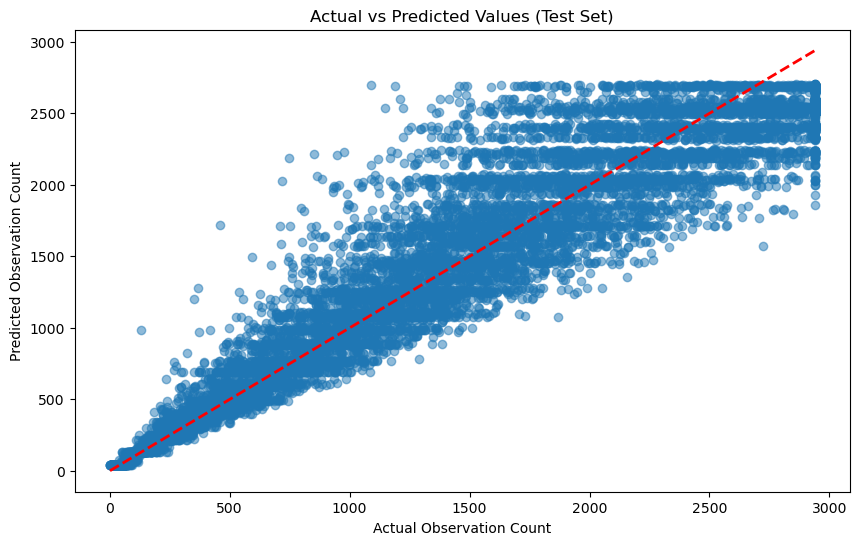

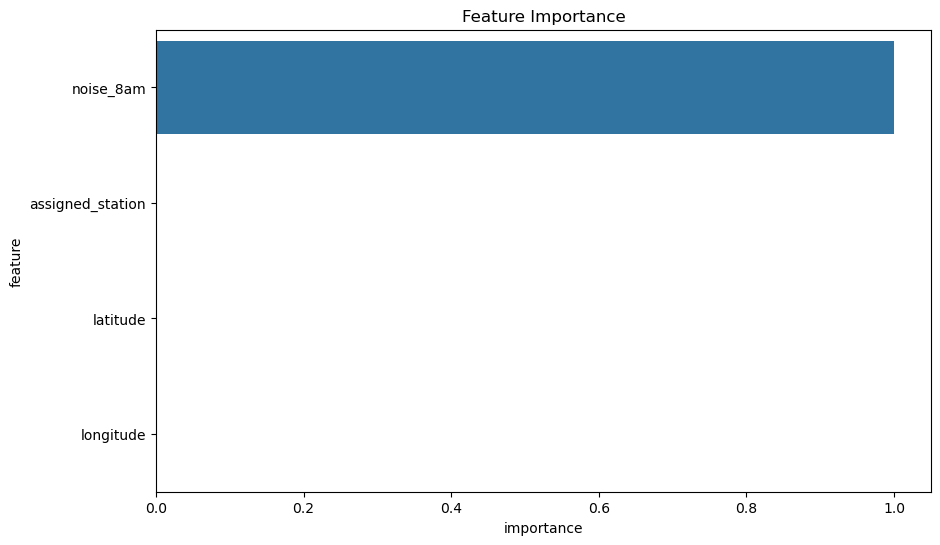

['best_model.joblib']

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

class PredictiveModel:
    def __init__(self, df, target='OBSERVATION COUNT', test_size=0.2, val_size=0.25):
        self.df = df
        self.target = target
        self.test_size = test_size
        self.val_size = val_size
        self.models = {}
        self.best_model = None
        self.best_score = float('-inf')
        
    def prepare_data(self):
        # Create feature matrix X and target vector y
        X = self.df.drop(columns=[self.target])
        y = self.df[self.target]
        
        # Encode categorical variables
        le = LabelEncoder()
        X['assigned_station'] = le.fit_transform(X['assigned_station'])
        
        # Split into train, validation, and test sets
        X_train_val, self.X_test, y_train_val, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=42
        )
        
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_train_val, y_train_val, test_size=self.val_size, random_state=42
        )
        
        # Scale features
        scaler = StandardScaler()
        self.X_train_scaled = scaler.fit_transform(self.X_train)
        self.X_val_scaled = scaler.transform(self.X_val)
        self.X_test_scaled = scaler.transform(self.X_test)
        
        # Store feature names
        self.feature_names = X.columns
        
        print("Data split sizes:")
        print(f"Training set: {self.X_train.shape[0]} samples")
        print(f"Validation set: {self.X_val.shape[0]} samples")
        print(f"Test set: {self.X_test.shape[0]} samples")

    def objective_rf(self, trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
        }
        model = RandomForestRegressor(**params, random_state=42)
        model.fit(self.X_train_scaled, self.y_train)
        predictions = model.predict(self.X_val_scaled)
        return r2_score(self.y_val, predictions)

    def objective_xgb(self, trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0)
        }
        model = XGBRegressor(**params, random_state=42)
        model.fit(self.X_train_scaled, self.y_train)
        predictions = model.predict(self.X_val_scaled)
        return r2_score(self.y_val, predictions)

    def objective_lgbm(self, trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100)
        }
        model = LGBMRegressor(**params, random_state=42)
        model.fit(self.X_train_scaled, self.y_train)
        predictions = model.predict(self.X_val_scaled)
        return r2_score(self.y_val, predictions)

    def train_models(self, n_trials=100):
        # Dictionary to store study results
        self.studies = {}
        
        # Train Random Forest
        study_rf = optuna.create_study(direction='maximize')
        study_rf.optimize(self.objective_rf, n_trials=n_trials)
        self.models['Random Forest'] = RandomForestRegressor(**study_rf.best_params, random_state=42)
        self.studies['Random Forest'] = study_rf

        # Train XGBoost
        study_xgb = optuna.create_study(direction='maximize')
        study_xgb.optimize(self.objective_xgb, n_trials=n_trials)
        self.models['XGBoost'] = XGBRegressor(**study_xgb.best_params, random_state=42)
        self.studies['XGBoost'] = study_xgb

        # Train LightGBM
        study_lgbm = optuna.create_study(direction='maximize')
        study_lgbm.optimize(self.objective_lgbm, n_trials=n_trials)
        self.models['LightGBM'] = LGBMRegressor(**study_lgbm.best_params, random_state=42)
        self.studies['LightGBM'] = study_lgbm

        # Train and evaluate all models
        results = []
        for name, model in self.models.items():
            # Train the model
            model.fit(self.X_train_scaled, self.y_train)
            
            # Make predictions on validation set
            val_predictions = model.predict(self.X_val_scaled)
            val_r2 = r2_score(self.y_val, val_predictions)
            val_rmse = np.sqrt(mean_squared_error(self.y_val, val_predictions))
            val_mae = mean_absolute_error(self.y_val, val_predictions)
            
            results.append({
                'Model': name,
                'R2 Score': val_r2,
                'RMSE': val_rmse,
                'MAE': val_mae,
                'Best Parameters': self.studies[name].best_params
            })
            
            # Update best model
            if val_r2 > self.best_score:
                self.best_score = val_r2
                self.best_model = model
        
        self.results_df = pd.DataFrame(results)
        print("\nModel Comparison on Validation Set:")
        print(self.results_df)

    def evaluate_best_model(self):
        # Make predictions on test set
        test_predictions = self.best_model.predict(self.X_test_scaled)
        
        # Calculate metrics
        test_r2 = r2_score(self.y_test, test_predictions)
        test_rmse = np.sqrt(mean_squared_error(self.y_test, test_predictions))
        test_mae = mean_absolute_error(self.y_test, test_predictions)
        
        print("\nBest Model Performance on Test Set:")
        print(f"R2 Score: {test_r2:.4f}")
        print(f"RMSE: {test_rmse:.4f}")
        print(f"MAE: {test_mae:.4f}")
        
        # Plot actual vs predicted values
        plt.figure(figsize=(10, 6))
        plt.scatter(self.y_test, test_predictions, alpha=0.5)
        plt.plot([self.y_test.min(), self.y_test.max()], 
                 [self.y_test.min(), self.y_test.max()], 
                 'r--', lw=2)
        plt.xlabel('Actual Observation Count')
        plt.ylabel('Predicted Observation Count')
        plt.title('Actual vs Predicted Values (Test Set)')
        plt.show()
        
        # Feature importance for tree-based models
        if hasattr(self.best_model, 'feature_importances_'):
            importance = pd.DataFrame({
                'feature': self.feature_names,
                'importance': self.best_model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            plt.figure(figsize=(10, 6))
            sns.barplot(data=importance, x='importance', y='feature')
            plt.title('Feature Importance')
            plt.show()

# Use the model
model = PredictiveModel(synthetic_df)
model.prepare_data()
model.train_models(n_trials=50)  # Reduced trials for demonstration
model.evaluate_best_model()

# Save the best model (optional)
import joblib
joblib.dump(model.best_model, 'best_model.joblib')

## Other stuff

In [ ]:
# Use the bounded_area polygon to filter your data
filtered_df = filter_by_bounded_area(df, bounded_polygon)

# If you need to filter the stations data:
filtered_stations = filter_by_bounded_area(scoped_stations, bounded_area)

# Print the number of points inside and outside the bounded area
print(f"Total points: {len(df)}")
print(f"Points inside bounded area: {len(filtered_df)}")
print(f"Points outside bounded area: {len(df) - len(filtered_df)}")

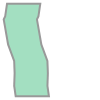

In [69]:
bounded_polygon

In [72]:


# Usage
save_polygon_to_json(bounded_polygon)

Successfully saved polygon to bounded_polygon.json


## Reading Parquet

In [98]:
import pandas as pd
import json
import numpy as np
from shapely.geometry import Point, Polygon
from shapely.vectorized import contains
import s3fs
import boto3

# Initialize boto3 session and get credentials
session = boto3.Session()
credentials = session.get_credentials()

# Initialize S3 filesystem with boto3 credentials
s3 = s3fs.S3FileSystem(
    key=credentials.access_key,
    secret=credentials.secret_key,
    token=credentials.token,  # This will be included if using temporary credentials
    anon=False
)
# Read the parquet file
s3_path = 's3://birdsbucker/ebd_US-VA_smp_relApr-2025.parquet'
df_birds = pd.read_parquet(s3_path, filesystem=s3)

# Load the bounded polygon
with open('bounded_polygon.json', 'r') as f:
    polygon_data = json.load(f)
    coordinates = polygon_data['geometry']['coordinates'][0]
    bounded_polygon = Polygon(coordinates)

# Create points array
points = np.column_stack((df_birds['LONGITUDE'].values, df_birds['LATITUDE'].values))

# Check which points are within polygon
mask = contains(bounded_polygon, points[:, 0], points[:, 1])

# Filter dataframe
df_birds_filtered = df_birds[mask].reset_index(drop=True)

print(f"Original dataset: {len(df_birds)} points")
print(f"Filtered dataset: {len(df_birds_filtered)} points")

Original dataset: 100000 points
Filtered dataset: 43 points


/tmp/ipykernel_181/212778073.py:34: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = contains(bounded_polygon, points[:, 0], points[:, 1])
